# Week 8 — Dynamic Optimisation I
## Optimal Control & the Maximum Principle

**Optimisation & Mathematical Methods for Economics**
The University of Edinburgh · School of Economics

---

Economics is inherently dynamic: agents save, invest, and plan over time. This week introduces **optimal control theory** — optimising a path through time rather than a single point.

## 1. The Calculus of Variations

**Problem:** Choose a function $y(t)$ to optimise

$$J[y] = \int_{t_0}^{t_1} F(t, y(t), \dot{y}(t)) \, dt$$

**Euler–Lagrange equation:** A necessary condition for an optimum:

$$\frac{\partial F}{\partial y} - \frac{d}{dt}\frac{\partial F}{\partial \dot{y}} = 0$$

## 2. Pontryagin's Maximum Principle

For the control problem $\max \int_0^T f(x,u,t)\,dt$ subject to $\dot{x} = g(x,u,t)$, $x(0)=x_0$:

Define the **Hamiltonian:** $H(x,u,\lambda,t) = f(x,u,t) + \lambda \, g(x,u,t)$

**Necessary conditions:**
1. $\frac{\partial H}{\partial u} = 0$ (optimality)
2. $\dot{\lambda} = -\frac{\partial H}{\partial x}$ (costate equation)
3. $\dot{x} = \frac{\partial H}{\partial \lambda}$ (state equation)
4. Transversality condition

## 3. The Ramsey–Cass–Koopmans Model

A social planner maximises $\int_0^\infty e^{-\rho t} u(c(t)) \, dt$ subject to $\dot{k} = f(k) - \delta k - c$.

The **Euler equation** (Keynes–Ramsey rule):

$$\frac{\dot{c}}{c} = \frac{1}{\sigma}[f'(k) - \delta - \rho]$$

where $\sigma$ is the elasticity of marginal utility.

Steady state: k* = 6.6076, c* = 1.4316


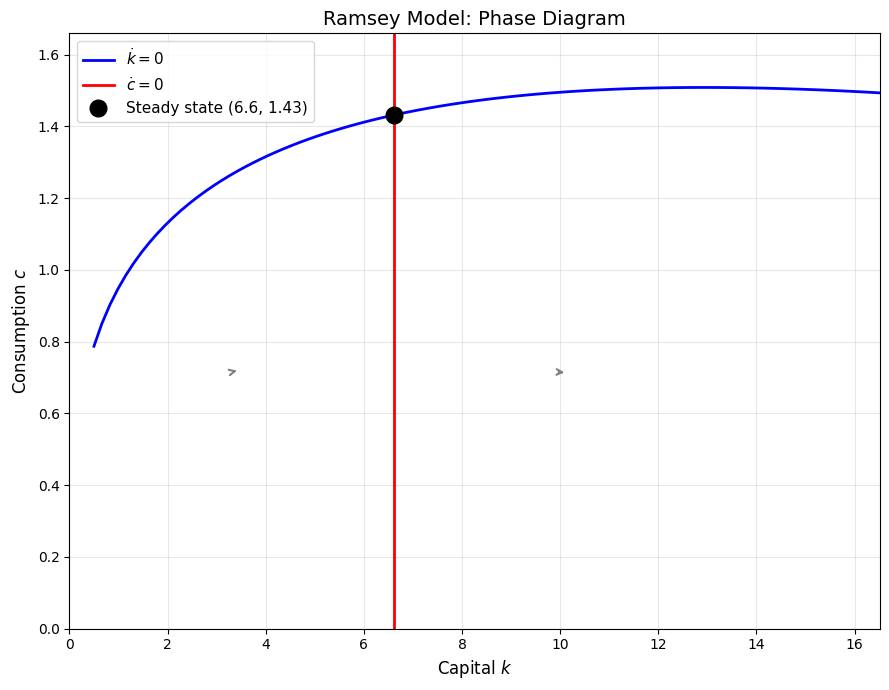

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Ramsey model phase diagram
alpha = 0.3    # capital share
delta = 0.05   # depreciation
rho = 0.03     # discount rate
sigma = 2.0    # CRRA parameter

# Steady state
k_ss = ((alpha)/(rho + delta))**(1/(1-alpha))
c_ss = k_ss**alpha - delta*k_ss
print(f"Steady state: k* = {k_ss:.4f}, c* = {c_ss:.4f}")

# Phase diagram
k_grid = np.linspace(0.5, k_ss*2.5, 100)
c_dot0 = k_grid**alpha - delta*k_grid  # c-dot = 0 locus (c = f(k) - delta*k)
k_dot0_k = k_ss * np.ones(100)         # k-dot = 0 locus (vertical at k*)

fig, ax = plt.subplots(figsize=(9, 7))
c_grid = np.linspace(0.1, max(c_dot0)*1.1, 100)
ax.plot(k_grid, c_dot0, 'b-', linewidth=2, label='$\dot{k}=0$')
ax.axvline(k_ss, color='r', linewidth=2, label='$\dot{c}=0$')
ax.plot(k_ss, c_ss, 'ko', markersize=12, zorder=5, label=f'Steady state ({k_ss:.1f}, {c_ss:.2f})')

# Direction arrows
for k_val in [k_ss*0.5, k_ss*1.5]:
    for c_val in [c_ss*0.5, c_ss*1.5]:
        dk = k_val**alpha - delta*k_val - c_val
        dc = c_val/sigma * (alpha*k_val**(alpha-1) - delta - rho)
        scale = 0.3
        ax.annotate('', xy=(k_val+dk*scale, c_val+dc*scale),
                   xytext=(k_val, c_val),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_xlabel('Capital $k$', fontsize=12)
ax.set_ylabel('Consumption $c$', fontsize=12)
ax.set_title('Ramsey Model: Phase Diagram', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, k_ss*2.5); ax.set_ylim(0, max(c_dot0)*1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

<details><summary><b>Exercise 1:</b> Derive the Euler equation for the Ramsey model using the Hamiltonian approach. Verify that the steady state satisfies $f'(k^*) = \rho + \delta$.</summary>

$H = e^{-\rho t} \frac{c^{1-\sigma}}{1-\sigma} + \lambda(k^\alpha - \delta k - c)$

FOC: $e^{-\rho t} c^{-\sigma} = \lambda$

Costate: $\dot{\lambda} = -\lambda(\alpha k^{\alpha-1} - \delta)$

Combining gives the Euler equation. At steady state $\dot{c}=0 \Rightarrow f'(k^*)=\rho+\delta$.
</details>